<a href="https://colab.research.google.com/github/hanleiwen/muon-computational-experiments/blob/main/Muon_Algorithm_(Testing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.linalg import qr
from scipy.stats import beta
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

# Initialization and Helpful Functions
The following parameters and helper functions should be helpful irrespective of the case we are testing the Muon and standard gradient descent algorithms in – in particular, the Newton-Schulz and the Stiefel draw functions are taken as a black box (I do not understand how they work exactly), and are used to compute the matrix sign of a matrix and to uniformly perform a random draw from the Stiefel manifold, i.e. $$St(d, k) = \{O \in \mathbb{R}^{d \times k} \ | \ O^TO = I_k\}$$

In [ ]:
### Generating an Orthogonal Matrix (from the Stiefel Manifold St(d, k)) ###
### Note here that d <= k ###
def Stiefel_draw(d, k):
  H = np.random.randn(d, d)
  Q, R = qr(H)
  return Q[:, :k]

### Computing the Matrix Sign using SVD ###
def matrix_sign(A):
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    return U @ Vt

### Generating Target Matrix (with singular values smaller than sigma_max) ###
def generate_target(m, n, r, sigma_max, kappa, rng_obj=None, report=False):

    if report:
        print("||Generating Target Matrix||")

    U = Stiefel_draw(m, n)
    V = Stiefel_draw(n, r)

    sigma_min = sigma_max / kappa
    singular_values = [sigma_max] + [sigma_min] * (r - 1)

    if report:
        print("Singular Values: ", singular_values)

    S = np.diag(singular_values)

    if report:
        print("Matrix Dimensions: ", U.shape, V.shape, S.shape)
        print("||Finished Generating Target Matrix||", end = "\n\n")

    return U @ S @ V.T

# Matrix Factorization (General Case)
Problem Statement: Try to factorize the matrix $M \in \mathbb{R}^{m \times n}$ by minimizing the loss function $$\min_{U, V} \frac{1}{2}||UV^T - M||^2$$
where $U \in \mathbb{R}^{m \times k}, V \in \mathbb{R}^{n \times k}$. We utilize both gradient descent and Muon gradient descent and compare their performances.

For now, we check the case where $r \leq k < \min\{m, n\}$ where $r$ is the rank of the matrix $M$. For now, we implement a similar strategy to the paper – https://arxiv.org/abs/2601.13474 – on matrix factorization.

In particular, the learning rate is taken to be $C\sqrt{\sigma_{max}}\rho^t$, and we apply standard and Muon gradient descent algorithms.

In [ ]:
### Objective Function ###
def fnval(U, V, M):
    return (np.linalg.norm((U @ V.T) - M, 'fro') ** 2) / np.linalg.norm(M, 'fro') ** 2

### Gradient of Objective Function ###
def gradfn(U, V, M):
    E = U @ V.T - M
    dU = E @ V
    dV = E.T @ U
    return dU, dV

## GD / Muon

In [ ]:
### Gradient Descent ###
def gradient_descent(U, V, M, sigma_max, ep, maxSteps=1e4):

    t = 0
    tol = ep * sigma_max

    learning_rate = 0.5 * np.sqrt(sigma_max)
    count = 0

    fn_vals = []
    fn_vals.append(fnval(U, V, M));

    while fn_vals[t] >= tol and fn_vals[t] <= 1e32 and t <= maxSteps:

        # if t % 1e4 == 0:
        #     print(f"Computing gradient descent iteration {t}, with function value {fn_vals[t]}.")

        dU, dV = gradfn(U, V, M)

        U = U - learning_rate * dU
        V = V - learning_rate * dV

        if t > 0 and abs(fn_vals[t] - fn_vals[t - 1]):
            count += 1
        else:
            count = 0

        if count == 50:
            learning_rate *= 0.3
            count = 0

        fn_vals.append(fnval(U, V, M));
        t += 1

    if t > maxSteps or fn_vals[t] > 1e10:
        print("Gradient descent did not converge.")
    else:
        print(f"Gradient descent converged in: {t} steps.")

    return fn_vals


### Muon ###
def Muon(U, V, M, sigma_max, ep, rho, maxSteps=1e4):

    # initialization step
    C = rng.uniform(1, 2)
    t = 0
    tol = ep * sigma_max

    learning_rate = C * np.sqrt(sigma_max)
    count = 0

    fn_vals = []
    fn_vals.append(fnval(U, V, M));

    while fn_vals[t] >= tol and fn_vals[t] <= 1e32 and t <= maxSteps:

        # if t % 1e4 == 0:
        #     print(f"Computing muon iteration {t}, with function value {fn_vals[t]}.")

        dU, dV = gradfn(U, V, M)
        dU = matrix_sign(dU)
        dV = matrix_sign(dV)

        U = U - learning_rate * dU
        V = V - learning_rate * dV

        learning_rate *= rho

        fn_vals.append(fnval(U, V, M));
        t += 1

    if t > maxSteps or fn_vals[t] > 1e10:
        print(f"Muon did not converge")
    else:
        print(f"Muon converged in: {t} steps.")

    return fn_vals


### Muon with robust learning rate ###
def Muon_with_robust_learning_rate(U, V, M, sigma_max, ep, maxSteps=1e4):
    # initialization step
    C = rng.uniform(1, 2)
    t = 0
    tol = ep * sigma_max

    learning_rate = C * np.sqrt(sigma_max)

    fn_vals = []
    fn_vals.append(fnval(U, V, M));

    while fn_vals[t] >= tol and fn_vals[t] <= 1e32 and t <= maxSteps:

        # if t % 1e4 == 0:
        #     print(f"Computing muon iteration {t}, with function value {fn_vals[t]}.")

        dU, dV = gradfn(U, V, M)
        dU = matrix_sign(dU)
        dV = matrix_sign(dV)

        U = U - learning_rate * dU
        V = V - learning_rate * dV

        if t > 0 and abs(fn_vals[t] - fn_vals[t - 1]):
            count += 1
        else:
            count = 0

        if count == 50:
            learning_rate *= 0.3
            count = 0

        fn_vals.append(fnval(U, V, M));
        t += 1

    if t > maxSteps or fn_vals[t] > 1e10:
        print(f"Muon did not converge")
    else:
        print(f"Muon converged in: {t} steps.")

    return fn_vals

## Function Verification

In [ ]:
### Verifying Matrix Generation ###
m, n, k, r = 100, 50, 5, 5
sigma_max = 5
alpha = 1e-5
kappa = 25

seed = 4
rng = np.random.default_rng(seed)

M = generate_target(m, n, r, sigma_max, kappa, rng, report=True)
print(f"Condition Number of M: {np.linalg.cond(M)}")

U_M, S_M, V_M = np.linalg.svd(M, full_matrices=True)
U_M, S_M, V_M = U_M[:, :k], S_M[:k], V_M[:, :k]
print(f"U_M: {U_M.shape}, V_M: {V_M.shape}, S_M: {S_M.shape}")
print(f"Singular Values: {S_M}")

def singular_values(M, r):
    _, S_M, _ = np.linalg.svd(M, full_matrices=True)
    return S_M[:r]

||Generating Target Matrix||
Singular Values:  [5, 0.2, 0.2, 0.2, 0.2]
Matrix Dimensions:  (100, 5) (50, 5) (5, 5)
||Finished Generating Target Matrix||

Condition Number of M: 1.2703408884175844e+18
U_M: (100, 5), V_M: (50, 5), S_M: (5,)
Singular Values: [5.  0.2 0.2 0.2 0.2]


## Computation Performance

In [ ]:
### Global Parameters -- regime where r <= k < d ###
m, n, k, r = 100, 50, 20, 5                 # (dimensions)
sigma_max = 5                               # (limit maximum singular value)
ep = 1e-12                                  # (ep scales wrt sigma_max -- see later)
rho = 0.90                                  # (learning rate decay param)
kappa = [1, 5, 25, 125, 625]                # (condition number)

seed = 4                                    # (for reproducibility)
rng = np.random.default_rng(seed)           # (rng object for reproducibility)

exactparametrized_gd_vals = []
exactparametrized_muon_vals = []

alpha = 1e-10
for kp in kappa:
    U = Stiefel_draw(m, k, rng) * alpha
    V = Stiefel_draw(n, k, rng) * alpha
    M = generate_target(m, n, r, sigma_max, kp, rng)

    S = singular_values(M, r)
    print("Singular Values: ", S)

    gd_val = gradient_descent(U, V, M, sigma_max, ep, maxSteps=1e4)
    sgd_val = Muon(U, V, M, sigma_max, ep, rho, maxSteps=1e4)
    # sgd_val = Muon_with_robust_learning_rate(U, V, M, sigma_max, ep, maxSteps=1e3)

    exactparametrized_gd_vals.append(gd_val)
    exactparametrized_muon_vals.append(sgd_val)

Singular Values:  [5. 5. 5. 5. 5.]
Gradient descent did not converge.
Muon converged in: 122 steps.
Singular Values:  [5. 1. 1. 1. 1.]
Gradient descent did not converge.
Muon converged in: 128 steps.
Singular Values:  [5.  0.2 0.2 0.2 0.2]
Gradient descent did not converge.
Muon converged in: 120 steps.
Singular Values:  [5.   0.04 0.04 0.04 0.04]
Gradient descent did not converge.
Muon converged in: 108 steps.
Singular Values:  [5.    0.008 0.008 0.008 0.008]
Gradient descent did not converge.
Muon converged in: 116 steps.


In [ ]:
### Global Parameters -- regime where k >= d ###
m, n, k, r = 100, 50, 150, 5                # (dimensions)
sigma_max = 1                               # (limit maximum singular value)
ep = 1e-12                                  # (ep scales wrt sigma_max -- see later)
rho = 0.90                                  # (learning rate decay param)
kappa = [1, 5, 25, 125, 625]                # (condition number)

seed = 42                                   # (for reproducibility)
rng = np.random.default_rng(42)             # (rng object for reproducibility)

overparametrized_gd_vals = []
overparametrized_muon_vals = []
alpha = 1e-10
for kp in kappa:
    U = Stiefel_draw(k, m, rng).T * alpha
    V = Stiefel_draw(k, n, rng).T * alpha
    M = generate_target(m, n, r, sigma_max, kp, rng)

    S = singular_values(M, r)
    print("Singular Values: ", S)

    gd_val = gradient_descent(U, V, M, sigma_max, ep, maxSteps=1e4)
    sgd_val = Muon(U, V, M, sigma_max, ep, rho, maxSteps=1e4)

    overparametrized_gd_vals.append(gd_val)
    overparametrized_muon_vals.append(sgd_val)

Singular Values:  [1. 1. 1. 1. 1.]
Gradient descent converged in: 62 steps.
Muon converged in: 139 steps.
Singular Values:  [1.  0.2 0.2 0.2 0.2]
Gradient descent did not converge.
Muon converged in: 137 steps.
Singular Values:  [1.   0.04 0.04 0.04 0.04]
Gradient descent did not converge.
Muon converged in: 133 steps.
Singular Values:  [1.    0.008 0.008 0.008 0.008]
Gradient descent did not converge.
Muon converged in: 128 steps.
Singular Values:  [1.     0.0016 0.0016 0.0016 0.0016]
Gradient descent did not converge.
Muon converged in: 122 steps.


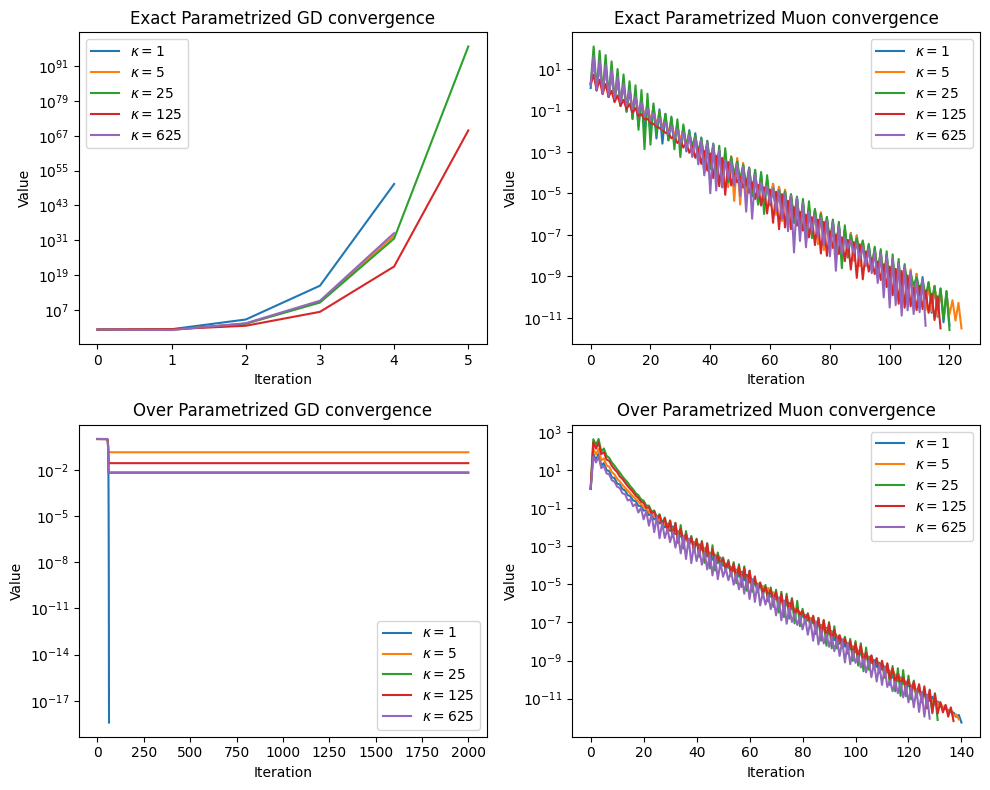

In [ ]:
### Plotting Objective Function value
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax in axes:
    ax.set_yscale("log")

for values, label in zip(exactparametrized_gd_vals, kappa):
    axes[0].plot(values[:200], label=rf"$\kappa = {label}$")
axes[0].set_title("Exact Parametrized GD convergence")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Value")
axes[0].legend()

for values, label in zip(exactparametrized_muon_vals, kappa):
    axes[1].plot(values[:200], label=rf"$\kappa = {label}$")
axes[1].set_title("Exact Parametrized Muon convergence")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Value")
axes[1].legend()

for values, label in zip(overparametrized_gd_vals, kappa):
    axes[2].plot(values[:2000], label=rf"$\kappa = {label}$")
axes[2].set_title("Over Parametrized GD convergence")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Value")
axes[2].legend()

for values, label in zip(overparametrized_muon_vals, kappa):
    axes[3].plot(values[:2000], label=rf"$\kappa = {label}$")
axes[3].set_title("Over Parametrized Muon convergence")
axes[3].set_xlabel("Iteration")
axes[3].set_ylabel("Value")
axes[3].legend()

plt.tight_layout()
plt.show()

In [ ]:
m, n, k, r = 100, 50, 20, 20                # (dimensions)
sigma_max = 1                               # (limit maximum singular value)
ep = 1e-12                                  # (ep scales wrt sigma_max -- see later)
kappa = [1, 5, 25, 125, 625]                # (condition number)

seed = 42                                   # (for reproducibility)
rng = np.random.default_rng(42)             # (rng object for reproducibility)

rho = 0.5
test1_muon = []
for kp in kappa:
    U = Stiefel_draw(m, k, rng)
    V = Stiefel_draw(n, k, rng)
    M = generate_target(m, n, r, sigma_max, kp, rng)

    muon_vals = Muon(U, V, M, sigma_max, ep, rho, maxSteps=1e4)
    test1_muon.append(muon_vals)

rho = 0.75
test2_muon = []
for kp in kappa:
    U = Stiefel_draw(m, k, rng)
    V = Stiefel_draw(n, k, rng)
    M = generate_target(m, n, r, sigma_max, kp, rng)

    muon_vals = Muon(U, V, M, sigma_max, ep, rho, maxSteps=1e4)
    test2_muon.append(muon_vals)

rho = 0.9
test3_muon = []
for kp in kappa:
    U = Stiefel_draw(m, k, rng)
    V = Stiefel_draw(n, k, rng)
    M = generate_target(m, n, r, sigma_max, kp, rng)

    muon_vals = Muon(U, V, M, sigma_max, ep, rho, maxSteps=1e4)
    test3_muon.append(muon_vals)

test4_muon = []
for kp in kappa:
    U = Stiefel_draw(m, k, rng)
    V = Stiefel_draw(n, k, rng)
    M = generate_target(m, n, r, sigma_max, kp, rng)

    muon_vals = Muon_with_robust_learning_rate(U, V, M, sigma_max, ep, maxSteps=1e4)
    test4_muon.append(muon_vals)


Muon did not converge
Muon did not converge
Muon did not converge
Muon did not converge
Muon did not converge
Muon did not converge
Muon did not converge
Muon did not converge
Muon did not converge
Muon did not converge
Muon converged in: 136 steps.
Muon converged in: 144 steps.
Muon converged in: 138 steps.
Muon converged in: 131 steps.
Muon converged in: 124 steps.
Muon converged in: 603 steps.
Muon converged in: 652 steps.
Muon converged in: 603 steps.
Muon converged in: 603 steps.
Muon converged in: 603 steps.


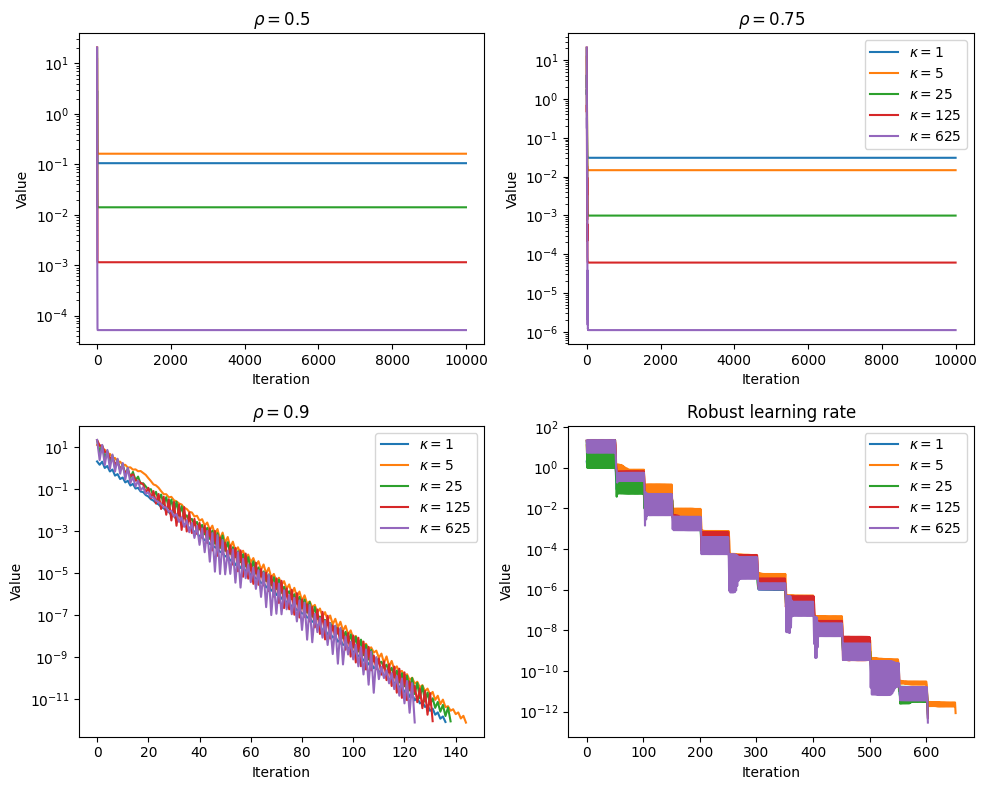

In [ ]:
### Plotting Objective Function value
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

kappa = [1, 5, 25, 125, 625]

for ax in axes:
    ax.set_yscale("log")

for values, label in zip(test1_muon, kappa):
    axes[0].plot(values[:10000], label=rf"$\kappa = {label}$")
axes[0].set_title(rf"$\rho = 0.5$")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Value")

for values, label in zip(test2_muon, kappa):
    axes[1].plot(values[:10000], label=rf"$\kappa = {label}$")
axes[1].set_title(rf"$\rho = 0.75$")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Value")
axes[1].legend()

for values, label in zip(test3_muon, kappa):
    axes[2].plot(values[:10000], label=rf"$\kappa = {label}$")
axes[2].set_title(rf"$\rho = 0.9$")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Value")
axes[2].legend()

for values, label in zip(test4_muon, kappa):
    axes[3].plot(values[:10000], label=rf"$\kappa = {label}$")
axes[3].set_title("Robust learning rate")
axes[3].set_xlabel("Iteration")
axes[3].set_ylabel("Value")
axes[3].legend()

plt.tight_layout()
plt.show()

# Matrix Regression
Problem Statement: Given $X \in \mathbb{R}^{n \times d}$ and $Y \in \mathbb{R}^{m \times d}$, we attempt to solve the following matrix regression task
$$\min_{W \in \mathbb{R}^{m \times n}} \frac{1}{2}\left|\left|WX - Y\right|\right|^2_F$$
where $W$ is seen as a solution to the matrix regression task. We utilize the functions and strategies defined in the previous section.

In [ ]:
### Objective Function ###
def matrix_regression_val(W, X, Y):
    return 0.5 * np.linalg.norm((W @ X - Y) ** 2)

### Gradient of Objective Function ###
def matrix_regression_grad(W, X, Y):
    E = (W @ X - Y)
    dW = E @ X.T
    return dW

In [ ]:
### Gradient Descent ###
def mr_gradient_descent(W, X, Y, sigma_max, ep, maxSteps=1e4):

    # initialization step
    C = rng.uniform(0.5, 1)
    t = 0
    tol = ep * sigma_max

    learning_rate = C * np.sqrt(sigma_max)
    count = 0

    fn_vals = []
    fn_vals.append(matrix_regression_val(W, X, Y));

    while fn_vals[t] >= tol and fn_vals[t] <= 1e32 and t <= maxSteps:

        if t % 1e4 == 0:
            print(f"Computing gradient descent iteration {t}, with function value {fn_vals[t]}.")

        dW = matrix_regression_grad(W, X, Y)

        W = W - learning_rate * dW

        if t > 0 and abs(fn_vals[t] - fn_vals[t - 1]):
            count += 1
        else:
            count = 0

        if count == 50:
            learning_rate *= 0.3
            count = 0

        fn_vals.append(matrix_regression_val(W, X, Y));
        t += 1

    if t > maxSteps or fn_vals[t] > 1e10:
        print("Gradient descent did not converge.")
    else:
        print(f"Gradient descent converged in: {t} steps.")

    return fn_vals

### Muon with robust learning rate ###
def mr_muon(W, X, Y, rho, sigma_max, ep, maxSteps=1e4):
    # initialization step
    C = rng.uniform(1, 2)
    t = 0
    tol = ep * sigma_max

    learning_rate = C * np.sqrt(sigma_max)

    fn_vals = []
    fn_vals.append(matrix_regression_val(W, X, Y));

    while fn_vals[t] >= tol and fn_vals[t] <= 1e32 and t <= maxSteps:

        if t % 1e4 == 0:
            print(f"Computing muon iteration {t}, with function value {fn_vals[t]}.")

        dW = matrix_regression_grad(W, X, Y)
        dW = matrix_sign(dW)

        W = W - learning_rate * dW

        # learning_rate = learning_rate * rho

        if t > 0 and abs(fn_vals[t] - fn_vals[t - 1]):
            count += 1
        else:
            count = 0

        if count == 50:
            learning_rate *= 0.3
            count = 0

        fn_vals.append(matrix_regression_val(W, X, Y));
        t += 1

    if t > maxSteps or fn_vals[t] > 1e10:
        print(f"Muon did not converge")
    else:
        print(f"Muon converged in: {t} steps.")

    return fn_vals

In [ ]:
### Global Parameters -- regime where r <= k < d ###
m, n, d, rX, rY = 20, 20, 20, 20, 20        # (dimensions)
sigma_max = 1                               # (limit maximum singular value)
ep = 1e-12                                  # (ep scales wrt sigma_max -- see later)
rho = 0.95                                  # (learning rate decay param)
kappa = [40, 50, 60, 70, 80, 90, 100]       # (condition number)

seed = 42                                   # (for reproducibility)
rng = np.random.default_rng(42)             # (rng object for reproducibility)

gd_vals = []
muon_vals = []
for kp in kappa:
    W = Stiefel_draw(m, n, rng)
    X = generate_target(n, d, rX, sigma_max, kp, rng)
    Y = generate_target(m, d, rY, sigma_max, kp, rng)

    gd_val = mr_gradient_descent(W, X, Y, sigma_max, ep, maxSteps=1e5)
    muon_val = mr_muon(W, X, Y, rho, sigma_max, ep, maxSteps=1e5)

    gd_vals.append(gd_val)
    muon_vals.append(muon_val)

TypeError: Stiefel_draw() takes 2 positional arguments but 3 were given

IndexError: slice() cannot be applied to a 0-dim tensor.

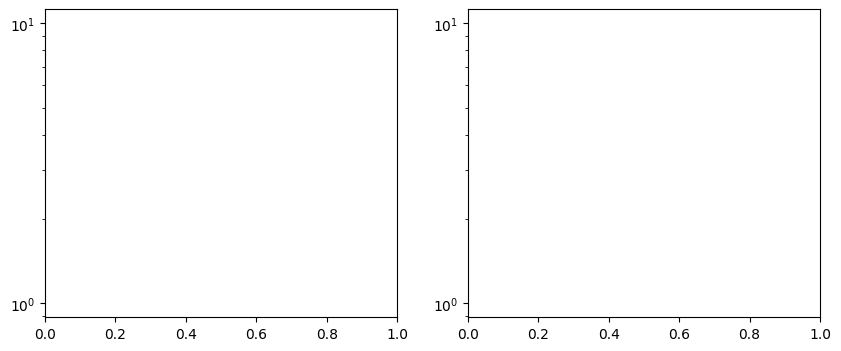

In [ ]:
### Plotting Objective Function value
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.ravel()

kappa = [40, 50, 60, 70, 80, 90, 100]

for ax in axes:
    ax.set_yscale("log")

for values, label in zip(gd_vals, kappa):
    axes[0].plot(values[:2000], label=rf"$\kappa = {label}$")
axes[0].set_title("Gradient Descent Values")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Value")
axes[0].legend()

for values, label in zip(muon_vals, kappa):
    axes[1].plot(values[:2000], label=rf"$\kappa = {label}$")
axes[1].set_title("Muon values")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Value")
axes[1].legend(loc = "upper right")

plt.tight_layout()
plt.show()

# Replication of Numerical Experiments
We replicate the numerical experiments exhibited in the paper "Insights on Muon from Simple Quadratics". In particular, we implement the experiment on the comparison between Gradient Descent and Muon on different spectral structures – which we elicit below. The problem is formulated as follows. Let $X \in \mathbb{R}^{n \times d_{in}}, Y \in \mathbb{R}^{n \times d_{out}}$. We attempt to find some $W \in \mathbb{R}^{d_{in} \times d_{out}}$ such that $XW = Y$. In particular, we minimize the loss:
$$L(W) = \frac{1}{2nd_{out}}\left|\left|XW - Y\right|\right|_F^2$$

In [2]:
### Some Helper Functions ###

### Gives a random orthogonal matrix ###
def stiefel_draw(n):
    M = torch.rand(n, n, dtype=torch.float32) # Ensure float32
    Q, R = torch.linalg.qr(M)
    return Q

### Modified version of function ###
def generate_target(n, evals):

    assert(n == len(evals))

    U = stiefel_draw(n)
    V = stiefel_draw(n)

    evals_tensor = torch.tensor(evals, dtype=torch.float32)
    svals = n * torch.sqrt(evals_tensor)
    S = torch.diag(svals)

    return U @ S @ V.T

### Matrix sign function ###
def matrix_sign(M, tol=1e-6, max_iter=100):
    U, S, Vt = torch.linalg.svd(M)
    return U @ Vt

In [3]:
### Function Value ###
def evaluate_function(n, X, W, Y):
    norm = torch.linalg.norm(X @ W - Y, 'fro')
    return (norm ** 2) / (2 * n * n)

### Function Gradient ###
def evaluate_gradient(n, X, W, Y):
    return X.T @ (X @ W - Y) / (n * n)

## GD / Muon


In [4]:
def gradient_descent(W, X, Y, lr, n):

    fn_vals = []
    fn_grads = []
    fn_vals.append(evaluate_function(n, X, W, Y))
    fn_grads.append(evaluate_gradient(n, X, W, Y))

    T = 0
    while T <= 500:
        W = W - lr * fn_grads[T]
        fn_vals.append(evaluate_function(n, X, W, Y))
        fn_grads.append(evaluate_gradient(n, X, W, Y))
        T += 1

    return fn_vals, fn_grads

def muon(W, X, Y, lr, n):

    fn_vals = []
    fn_grads = []
    fn_vals.append(evaluate_function(n, X, W, Y))
    fn_grads.append(evaluate_gradient(n, X, W, Y))

    T = 0
    while T <= 500:
        W = W - lr * matrix_sign(fn_grads[T])
        fn_vals.append(evaluate_function(n, X, W, Y))
        fn_grads.append(evaluate_gradient(n, X, W, Y))
        T += 1

    return fn_vals, fn_grads

## Eigenspectrum Generation

In [5]:
n = 100
smin, smax = 1e-3, 1e1

max_spiked = [smax] * (n - 1) + [smin] * 1
min_spiked = [smax] * 1 + [smin] * (n - 1)

uniform = np.random.uniform(smin, smax, n).tolist()
uniform.sort()
uniform[0] = smax
uniform[n - 1] = smin

k = 3
mid = (smax + smin) / 2
sigma = (smax - smin) / (2 * k)
z = np.clip(np.random.randn(n), -k, k)
gaussian = (mid + sigma * z).tolist()
gaussian.sort()
gaussian[0], gaussian[n - 1] = smax, smin

u = np.random.uniform(0, 1, n)
linear_decay_to_max = (smax - (smax - smin) * np.sqrt(u)).tolist()
linear_decay_to_max.sort()
linear_decay_to_max[0], linear_decay_to_max[n - 1] = smax, smin

geometric_decay_to_max = [smax]
q = 0.9
for i in range(n - 1):
    geometric_decay_to_max.append(max(geometric_decay_to_max[-1] * q, smin))
geometric_decay_to_max[n - 1] = smin

z_beta = beta(0.2, 0.2)
u_shaped = smin + (smax - smin) * z_beta.rvs(size=n)
u_shaped.sort()
u_shaped[0], u_shaped[n - 1] = smax, smin

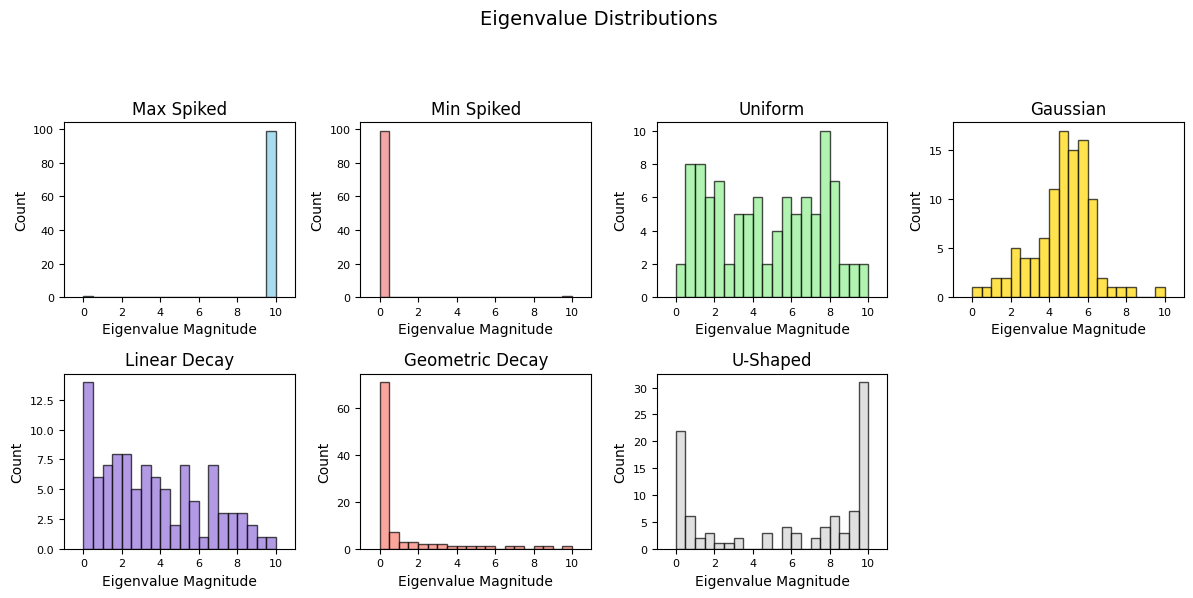

In [6]:
### Checking whether the spectral shapes have been generated correctly ###
distributions = {
    'Max Spiked': max_spiked,
    'Min Spiked': min_spiked,
    'Uniform': uniform,
    'Gaussian': gaussian,
    'Linear Decay': linear_decay_to_max,
    'Geometric Decay': geometric_decay_to_max,
    'U-Shaped': u_shaped
}

# Plotting
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

fig.suptitle('Eigenvalue Distributions', fontsize=14, y=1.02)
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple', 'salmon', 'lightgray']

for i, (name, values) in enumerate(distributions.items()):
    if i < len(axes):
        axes[i].hist(values, bins=20, alpha=0.7, color=colors[i % len(colors)], edgecolor='black')
        axes[i].set_title(name, fontsize=12)
        axes[i].set_xlabel('Eigenvalue Magnitude', fontsize=10)
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].tick_params(axis='both', which='major', labelsize=8)
        axes[i].set_xlim(smin - (smax - smin)*0.1, smax + (smax - smin)*0.1)
    else:
        print(f"Warning: Not enough subplots for {name} distribution.")

for j in range(len(distributions), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Numerical Testing

In [7]:
### Fix a ground truth matrix ###
W = torch.randn(n, n, dtype=torch.float32)
eta_list = [1e-1, 1e-2, 1e-3]

gd_loss_list = []
muon_loss_list = []
for i, (name, values) in enumerate(distributions.items()):
    X = generate_target(n, values)
    Y = X @ W
    W_0 = torch.randn(n, n, dtype=torch.float32) * (1 / np.sqrt(n))

    gd_compare = []
    muon_compare = []

    print(f"Processing spectral shape {i + 1}.")
    for lr in eta_list:
        W_gd_init = W_0.clone()
        W_muon_init = W_0.clone()

        gd_vals, gd_grads = gradient_descent(W_gd_init, X, Y, lr, n)
        muon_vals, muon_grads = muon(W_muon_init, X, Y, lr, n)

        gd_compare.append(gd_vals)
        muon_compare.append(muon_vals)

    final_gd = min(gd_compare, key=lambda x: x[-1])
    final_muon = min(muon_compare, key=lambda x: x[-1])

    gd_loss_list.append(final_gd)
    muon_loss_list.append(final_muon)

    print(f"Finished processing spectral shape {i + 1}.")

Processing spectral shape 1.
Finished processing spectral shape 1.
Processing spectral shape 2.
Finished processing spectral shape 2.
Processing spectral shape 3.
Finished processing spectral shape 3.
Processing spectral shape 4.
Finished processing spectral shape 4.
Processing spectral shape 5.
Finished processing spectral shape 5.
Processing spectral shape 6.
Finished processing spectral shape 6.
Processing spectral shape 7.
Finished processing spectral shape 7.


           Algorithm            Shape  Orders_Decrease
0   Gradient Descent       Max Spiked         6.035521
1               Muon       Max Spiked         4.554077
2   Gradient Descent       Min Spiked         2.074843
3               Muon       Min Spiked         4.168646
4   Gradient Descent          Uniform         5.750520
5               Muon          Uniform         4.603810
6   Gradient Descent         Gaussian         5.827896
7               Muon         Gaussian         4.546584
8   Gradient Descent     Linear Decay         5.022618
9               Muon     Linear Decay         4.584970
10  Gradient Descent  Geometric Decay         3.016543
11              Muon  Geometric Decay         4.596023
12  Gradient Descent         U-Shaped         4.197852
13              Muon         U-Shaped         4.599130


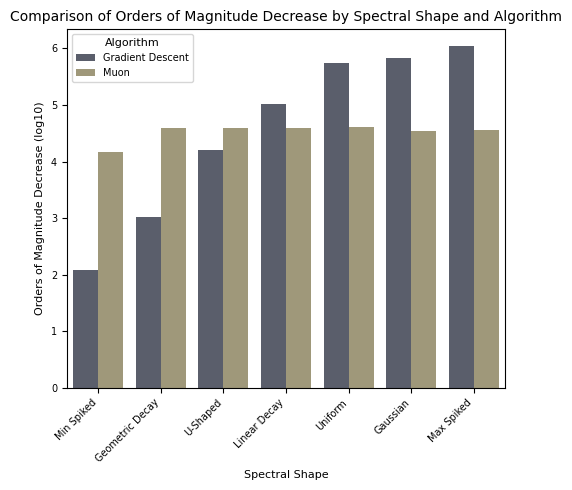

In [ ]:
plot_data = []
spectral_shape_names = list(distributions.keys())

for i, shape_name in enumerate(spectral_shape_names):
    gd_initial_loss = gd_loss_list[i][0].item()
    gd_final_loss = gd_loss_list[i][-1].item()
    muon_initial_loss = muon_loss_list[i][0].item()
    muon_final_loss = muon_loss_list[i][-1].item()

    # Calculate orders of magnitude decrease
    gd_orders_decrease = np.log10(gd_initial_loss / gd_final_loss) if gd_final_loss != 0 else np.inf
    muon_orders_decrease = np.log10(muon_initial_loss / muon_final_loss) if muon_final_loss != 0 else np.inf

    plot_data.append({
        'Algorithm': 'Gradient Descent',
        'Shape': shape_name,
        'Orders_Decrease': gd_orders_decrease
    })
    plot_data.append({
        'Algorithm': 'Muon',
        'Shape': shape_name,
        'Orders_Decrease': muon_orders_decrease
    })

df_plot_data = pd.DataFrame(plot_data)

print(df_plot_data)

gd_order = df_plot_data[df_plot_data['Algorithm'] == 'Gradient Descent'].sort_values(by='Orders_Decrease')['Shape'].tolist()

plt.figure(figsize=(5, 5))
sns.barplot(x='Shape', y='Orders_Decrease', hue='Algorithm', data=df_plot_data, palette='cividis', order=gd_order) # Use the sorted order
plt.xlabel('Spectral Shape', fontsize=8)
plt.ylabel('Orders of Magnitude Decrease (log10)', fontsize=8)
plt.title('Comparison of Orders of Magnitude Decrease by Spectral Shape and Algorithm', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.legend(title='Algorithm', fontsize=7, title_fontsize=8)
plt.tight_layout()
plt.show()

# Comparisons with Matrix Factorization
We now come back to the problem of matrix factorization and attempt to view whether we have a similar pattern. In particular, recall we are solving the problem for $M \in \mathbb{R}^{m \times n}$, $$\min_{U, V} \frac{1}{2}\left|\left|UV^T - M\right|\right|_F^2$$


where $U \in \mathbb{R}^{m \times k}, V^T \in \mathbb{R}^{n \times k}$. For now, we test on the symmetric case, where $k = m = n$.

In [ ]:
### function value ###
def evaluate_matrix_factorization(n, U, V, M):
    return 0.5 * (torch.linalg.norm(U @ V - M, 'fro') ** 2)

### function gradient ###
def gradient_matrix_factorization(n, U, V, M):
    E = U @ V.T - M
    dU = E @ V
    dV = E.T @ U
    return dU, dV

In [ ]:
def gradient_descent(U, V, M, lr, n):

    fn_vals = []
    fn_grads = []
    fn_vals.append(evaluate_matrix_factorization(n, U, V, M))
    fn_grads.append(gradient_matrix_factorization(n, U, V, M))

    T = 0
    while T <= 500:
        dU, dV = fn_grads[T]
        U = U - lr * dU
        V = V - lr * dV

        fn_vals.append(evaluate_matrix_factorization(n, U, V, M))
        fn_grads.append(gradient_matrix_factorization(n, U, V, M))
        T += 1

    return fn_vals, fn_grads

def muon(U, V, M, lr, n):

    fn_vals = []
    fn_grads = []
    fn_vals.append(evaluate_matrix_factorization(n, U, V, M))
    fn_grads.append(gradient_matrix_factorization(n, U, V, M))

    T = 0
    while T <= 500:
        dU, dV = fn_grads[T]
        U = U - lr * matrix_sign(dU)
        V = V - lr * matrix_sign(dV)

        fn_vals.append(evaluate_matrix_factorization(n, U, V, M))
        fn_grads.append(gradient_matrix_factorization(n, U, V, M))
        T += 1

    return fn_vals, fn_grads

def muon_vanishing_lr(U, V, M, lr, rho, n):

    lr_v = lr

    fn_vals = []
    fn_grads = []
    fn_vals.append(evaluate_matrix_factorization(n, U, V, M))
    fn_grads.append(gradient_matrix_factorization(n, U, V, M))

    T = 0
    while T <= 500:
        dU, dV = fn_grads[T]
        U = U - lr_v * matrix_sign(dU)
        V = V - lr_v * matrix_sign(dV)

        fn_vals.append(evaluate_matrix_factorization(n, U, V, M))
        fn_grads.append(gradient_matrix_factorization(n, U, V, M))
        lr_v *= rho
        T += 1

    return fn_vals, fn_grads

In [ ]:
### Fix a ground truth matrix ###
eta_list = [1e-1, 1e-2, 1e-3]

gd_loss_list = []
muon_loss_list = []
for i, (name, values) in enumerate(distributions.items()):
    M = generate_target(n, values)
    U_0, V_0 = stiefel_draw(n), stiefel_draw(n)

    gd_compare = []
    muon_compare = []

    print(f"Processing spectral shape {i + 1}.")
    for lr in eta_list:
        U_gd_init = U_0.clone()
        V_gd_init = V_0.clone()
        U_muon_init = U_0.clone()
        V_muon_init = V_0.clone()

        gd_vals, gd_grads = gradient_descent(U_gd_init, V_gd_init, M, lr, n)
        muon_vals, muon_grads = muon(U_muon_init, V_muon_init, M, lr, n)

        gd_compare.append(gd_vals)
        muon_compare.append(muon_vals)

    final_gd = min(gd_compare, key=lambda x: x[-1])
    final_muon = min(muon_compare, key=lambda x: x[-1])

    gd_loss_list.append(final_gd)
    muon_loss_list.append(final_muon)

    print(f"Finished processing spectral shape {i + 1}.")

Processing spectral shape 1.
Finished processing spectral shape 1.
Processing spectral shape 2.
Finished processing spectral shape 2.
Processing spectral shape 3.
Finished processing spectral shape 3.
Processing spectral shape 4.
Finished processing spectral shape 4.
Processing spectral shape 5.
Finished processing spectral shape 5.
Processing spectral shape 6.
Finished processing spectral shape 6.
Processing spectral shape 7.
Finished processing spectral shape 7.


In [ ]:
muon_vanish_loss_list = []
for i, (name, values) in enumerate(distributions.items()):
    M = generate_target(n, values)
    U_0, V_0 = stiefel_draw(n), stiefel_draw(n)

    print(f"Processing spectral shape {i + 1}.")
    rho = 0.95
    C = 0.01
    gd_vals, gd_grads = muon_vanishing_lr(U_0, V_0, M, C, rho, n)
    muon_vanish_loss_list.append(gd_vals)

Processing spectral shape 1.
Processing spectral shape 2.
Processing spectral shape 3.
Processing spectral shape 4.
Processing spectral shape 5.
Processing spectral shape 6.
Processing spectral shape 7.


                 Algorithm            Shape  Orders_Decrease
0         Gradient Descent       Max Spiked              NaN
1                     Muon       Max Spiked        -0.000068
2   Muon with vanishing lr       Max Spiked        -0.000007
3         Gradient Descent       Min Spiked              NaN
4                     Muon       Min Spiked        -0.000235
5   Muon with vanishing lr       Min Spiked         0.000021
6         Gradient Descent          Uniform              NaN
7                     Muon          Uniform        -0.000059
8   Muon with vanishing lr          Uniform        -0.000033
9         Gradient Descent         Gaussian              NaN
10                    Muon         Gaussian        -0.000107
11  Muon with vanishing lr         Gaussian        -0.000041
12        Gradient Descent     Linear Decay              NaN
13                    Muon     Linear Decay        -0.000140
14  Muon with vanishing lr     Linear Decay        -0.000023
15        Gradient Desce

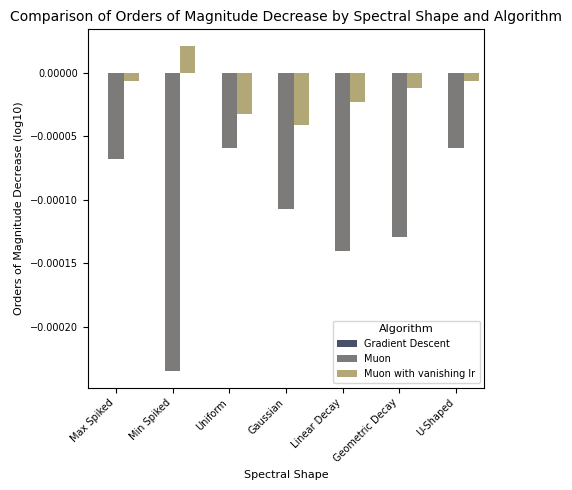

In [ ]:
plot_data = []
spectral_shape_names = list(distributions.keys())

for i, shape_name in enumerate(spectral_shape_names):
    gd_initial_loss = gd_loss_list[i][0].item()
    gd_final_loss = gd_loss_list[i][-1].item()
    muon_initial_loss = muon_loss_list[i][0].item()
    muon_final_loss = muon_loss_list[i][-1].item()
    vanish_initial_loss = muon_vanish_loss_list[i][0].item()
    vanish_final_loss = muon_vanish_loss_list[i][-1].item()

    # Calculate orders of magnitude decrease
    gd_orders_decrease = np.log10(gd_initial_loss / gd_final_loss) if gd_final_loss != 0 else np.inf
    muon_orders_decrease = np.log10(muon_initial_loss / muon_final_loss) if muon_final_loss != 0 else np.inf
    vanish_orders_decrease = np.log10(vanish_initial_loss / vanish_final_loss) if vanish_final_loss != 0 else np.inf

    plot_data.append({
        'Algorithm': 'Gradient Descent',
        'Shape': shape_name,
        'Orders_Decrease': gd_orders_decrease
    })
    plot_data.append({
        'Algorithm': 'Muon',
        'Shape': shape_name,
        'Orders_Decrease': muon_orders_decrease
    })
    plot_data.append({
        'Algorithm': 'Muon with vanishing lr',
        'Shape': shape_name,
        'Orders_Decrease': vanish_orders_decrease
    })

df_plot_data = pd.DataFrame(plot_data)

print(df_plot_data)

gd_order = df_plot_data[df_plot_data['Algorithm'] == 'Gradient Descent'].sort_values(by='Orders_Decrease')['Shape'].tolist()

plt.figure(figsize=(5, 5))
sns.barplot(x='Shape', y='Orders_Decrease', hue='Algorithm', data=df_plot_data, palette='cividis', order=gd_order) # Use the sorted order
plt.xlabel('Spectral Shape', fontsize=8)
plt.ylabel('Orders of Magnitude Decrease (log10)', fontsize=8)
plt.title('Comparison of Orders of Magnitude Decrease by Spectral Shape and Algorithm', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.legend(title='Algorithm', fontsize=7, title_fontsize=8)
plt.tight_layout()
plt.show()

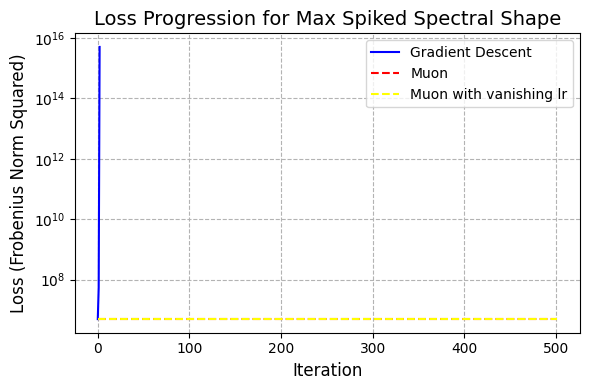

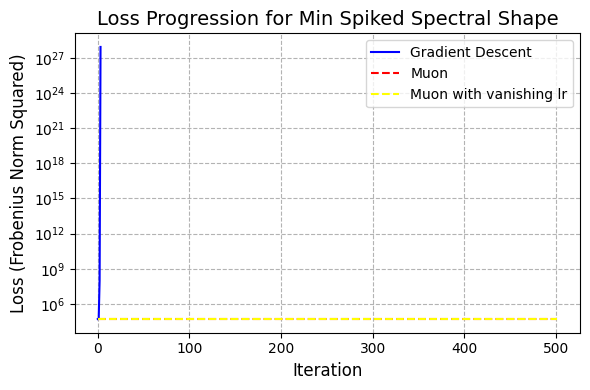

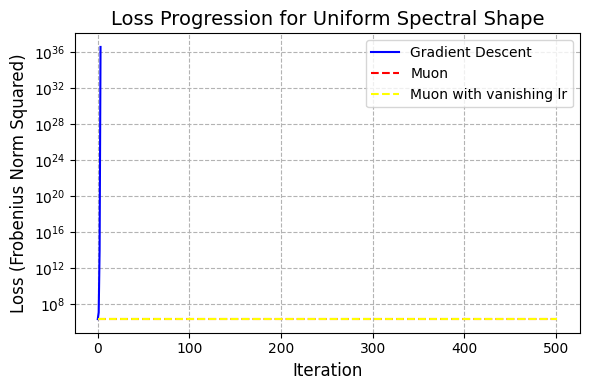

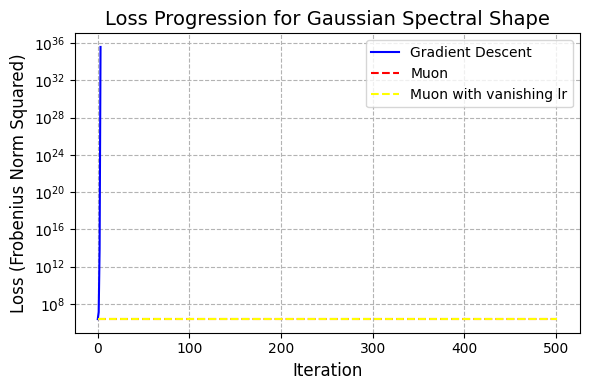

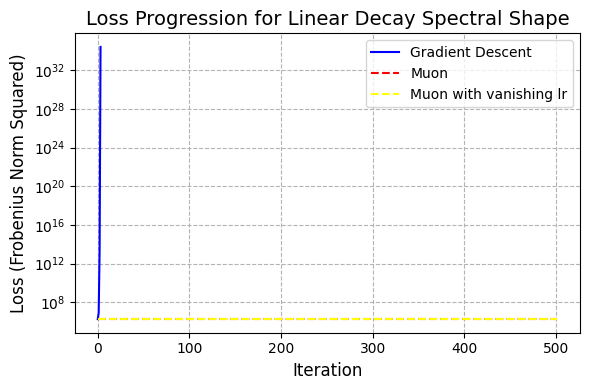

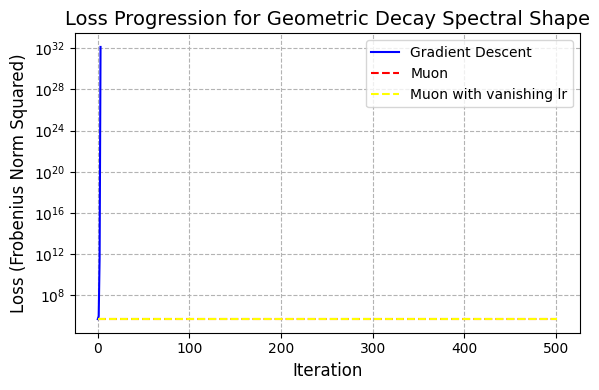

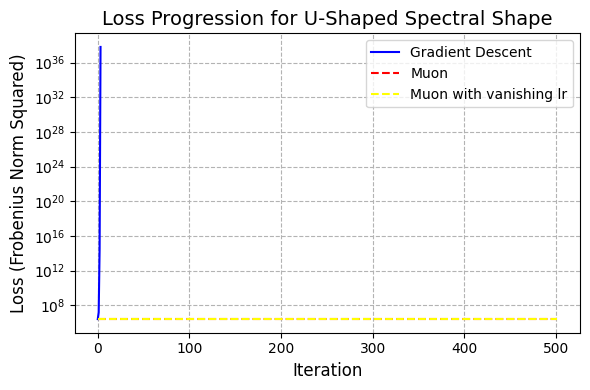

In [ ]:
for i, spectral_shape in enumerate(spectral_shape_names):
    gd_losses = gd_loss_list[i]
    muon_losses = muon_loss_list[i]
    vanish_losses = muon_vanish_loss_list[i]

    # Convert torch tensors to numpy arrays if necessary for plotting
    gd_losses_np = [val.item() if hasattr(val, 'item') else val for val in gd_losses]
    muon_losses_np = [val.item() if hasattr(val, 'item') else val for val in muon_losses]
    vanish_losses_np = [val.item() if hasattr(val, 'item') else val for val in vanish_losses]

    plt.figure(figsize=(6, 4))
    plt.plot(gd_losses_np, label='Gradient Descent', color='blue', linestyle='-')
    plt.plot(muon_losses_np, label='Muon', color='red', linestyle='--')
    plt.plot(vanish_losses_np, label='Muon with vanishing lr', color='yellow', linestyle='--')

    plt.title(f'Loss Progression for {spectral_shape} Spectral Shape', fontsize=14)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Loss (Frobenius Norm Squared)', fontsize=12)
    plt.yscale('log') # Use a logarithmic scale for the y-axis
    plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--", c='0.7')
    plt.tight_layout()
    plt.show()